In [46]:
TEST_COL = ['sex', 'length','diameter','height','whole_weight','shucked_weight','viscera_weight','shell_weight']

Colunas usadas: ['height', 'whole_weight', 'diameter', 'shell_weight']

=== Validação cruzada (10 partições) ===
                 média  desvio
acuracia        0.6236  0.0222
f1_macro        0.6158  0.0231
f1_ponderado    0.6191  0.0228
precisao_macro  0.6155  0.0234
recall_macro    0.6197  0.0226
auc_ovr         0.8102  0.0153

=== Relatório por tipo ===
              precision    recall  f1-score   support

      Tipo 1     0.7061    0.7866    0.7442      1078
      Tipo 2     0.4883    0.4566    0.4719      1003
      Tipo 3     0.6516    0.6156    0.6331      1051

    accuracy                         0.6236      3132
   macro avg     0.6153    0.6196    0.6164      3132
weighted avg     0.6180    0.6236    0.6197      3132

Matriz de confusão (linhas = real, colunas = previsto):
             prev Tipo 1  prev Tipo 2  prev Tipo 3
real Tipo 1          848          188           42
real Tipo 2          241          458          304
real Tipo 3          112          292          647



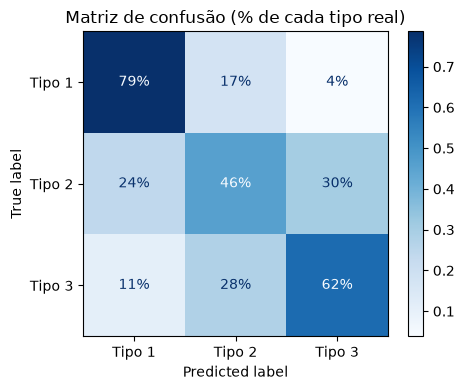

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("abalone_dataset.csv")

# ===== CONFIGURAÇÃO =====
TARGET_COL = "type"
FEATURE_COLS = ['sex',"length", "diameter", "height", "whole_weight",
                "shucked_weight", "viscera_weight", "shell_weight"]   # inclua "sex" para usá-lo
K = 10
C = 1.0   # força da regularização (menor = mais regularizado)

X = df[FEATURE_COLS].copy()
X = X[X['sex'] != 'I'];
if "sex" in FEATURE_COLS:
    X = pd.get_dummies(X, columns=["sex"], drop_first=True, dtype=float)   # cria sex_I e sex_M
y = df[TARGET_COL]
classes = sorted(y.unique())
nomes = [f"Tipo {c}" for c in classes]

modelo = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000, random_state=42))
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

# 1. Métricas em cada partição (média e desvio)
scoring = {"acuracia": "accuracy", "f1_macro": "f1_macro", "f1_ponderado": "f1_weighted",
           "precisao_macro": "precision_macro", "recall_macro": "recall_macro",
           "auc_ovr": "roc_auc_ovr"}
res = cross_validate(modelo, X, y, cv=skf, scoring=scoring)
resumo = pd.DataFrame({m: [res[f"test_{m}"].mean(), res[f"test_{m}"].std()] for m in scoring},
                      index=["média", "desvio"]).T
print(f"Colunas usadas: {list(X.columns)}")
print(f"\n=== Validação cruzada ({K} partições) ===")
print(resumo.round(4))

# 2. Relatório por tipo (previsão de cada linha quando ela ficou fora do treino)
y_pred = cross_val_predict(modelo, X, y, cv=skf)
print("\n=== Relatório por tipo ===")
print(classification_report(y, y_pred, digits=4, target_names=nomes))

cm = confusion_matrix(y, y_pred, labels=classes)
print("Matriz de confusão (linhas = real, colunas = previsto):")
print(pd.DataFrame(cm, index=[f"real {n}" for n in nomes], columns=[f"prev {n}" for n in nomes]))

# 3. Coeficientes do modelo treinado com todos os dados (colunas padronizadas)
modelo.fit(X, y)
coef = pd.DataFrame(modelo[-1].coef_.T, index=X.columns, columns=nomes)
print("\n=== Coeficientes (colunas padronizadas) ===")
print(coef.round(3))

# 4. Gráfico da matriz de confusão (em %, por linha)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y, y_pred, display_labels=nomes, normalize="true",
                                        values_format=".0%", cmap="Blues", ax=ax)
ax.set_title("Matriz de confusão (% de cada tipo real)")
plt.tight_layout()
plt.show()

=== 10 melhores (por F1 macro) ===
              combinacao               modelo  n_colunas  acuracia_media  acuracia_desvio  f1_macro_media  f1_macro_desvio  f1_tipo1_media  f1_tipo2_media  f1_tipo3_media
0            todas + sex  Regressão logística          9          0.6539           0.0211          0.6507           0.0220          0.7540          0.5258          0.6723
1              todas (7)  Regressão logística          7          0.6529           0.0223          0.6484           0.0223          0.7498          0.5194          0.6760
2           só pesos (4)  Regressão logística          4          0.6523           0.0260          0.6446           0.0261          0.7532          0.5045          0.6761
3              5 colunas  Regressão logística          5          0.6509           0.0212          0.6444           0.0212          0.7513          0.5061          0.6757
4        5 colunas + sex  Regressão logística          7          0.6494           0.0215          0.6441     

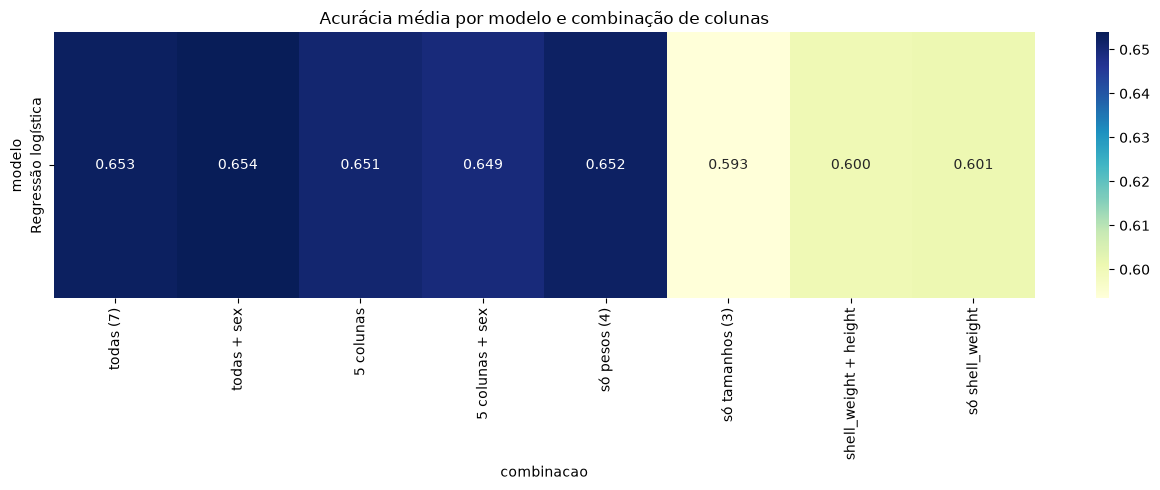

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score

df = pd.read_csv("abalone_dataset.csv")
TARGET_COL = "type"
y = df[TARGET_COL]
tipos = sorted(y.unique())

# ===== CONFIGURAÇÃO =====
TODAS = ["length", "diameter", "height", "whole_weight",
         "shucked_weight", "viscera_weight", "shell_weight"]
CINCO = ["height", "whole_weight", "shucked_weight", "viscera_weight", "shell_weight"]

COMBINACOES = {
    "todas (7)": TODAS,
    "todas + sex": TODAS + ["sex"],
    "5 colunas": CINCO,
    "5 colunas + sex": CINCO + ["sex"],
    "só pesos (4)": ["whole_weight", "shucked_weight", "viscera_weight", "shell_weight"],
    "só tamanhos (3)": ["length", "diameter", "height"],
    "shell_weight + height": ["shell_weight", "height"],
    "só shell_weight": ["shell_weight"],
}

MODELOS = {
    "Regressão logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42)),
}

# Mesmas partições para todos os modelos e combinações
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

scoring = {"acuracia": "accuracy", "f1_macro": "f1_macro", "f1_ponderado": "f1_weighted"}
for t in tipos:
    scoring[f"f1_tipo{t}"] = make_scorer(f1_score, labels=[t], average="macro")

def montar_X(colunas):
    X = df[colunas].copy()
    if "sex" in colunas:
        X = pd.get_dummies(X, columns=["sex"], drop_first=True, dtype=float)
    return X

# ===== EXECUÇÃO =====
linhas = []
for nome_comb, colunas in COMBINACOES.items():
    X = montar_X(colunas)
    for nome_modelo, modelo in MODELOS.items():
        res = cross_validate(modelo, X, y, cv=cv, scoring=scoring)
        linha = {"combinacao": nome_comb, "modelo": nome_modelo, "n_colunas": X.shape[1]}
        for m in scoring:
            linha[f"{m}_media"] = res[f"test_{m}"].mean()
            if m in ("acuracia", "f1_macro"):
                linha[f"{m}_desvio"] = res[f"test_{m}"].std()
        linhas.append(linha)

resultados = pd.DataFrame(linhas).sort_values("f1_macro_media", ascending=False).reset_index(drop=True)

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 30)
colunas_tabela = ["combinacao", "modelo", "n_colunas", "acuracia_media", "acuracia_desvio",
                  "f1_macro_media", "f1_macro_desvio"] + [f"f1_tipo{t}_media" for t in tipos]

print("=== 10 melhores (por F1 macro) ===")
print(resultados[colunas_tabela].head(10).round(4).to_string())

# Mapa de calor: acurácia de cada modelo em cada combinação
tabela_acuracia = resultados.pivot(index="modelo", columns="combinacao", values="acuracia_media")
tabela_acuracia = tabela_acuracia[list(COMBINACOES.keys())]
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(tabela_acuracia, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("Acurácia média por modelo e combinação de colunas")
plt.tight_layout()
plt.show()

# resultados.to_csv("resultados.csv", index=False)   # descomente para salvar a tabela